In [1]:
# imports
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_recall_fscore_support

from functions import clean, split_data, train_and_test_model, evaluate_predictions

In [2]:
#load data
MRSA_df = pd.read_csv("MRSA_synthetic.csv")
VRE_df = pd.read_csv("VRE_synthetic.csv")
CRE_df = pd.read_csv("CRE_synthetic.csv")

print(MRSA_df.columns.tolist())
print(VRE_df.columns.tolist())
print(CRE_df.columns.tolist())


['anon_id', 'pat_enc_csn_id_coded', 'order_proc_id_coded', 'order_time_jittered_utc', 'ordering_mode', 'culture_description', 'was_positive', 'organism', 'antibiotic', 'susceptibility', 'label', 'neg_group', 'clinical_report']
['anon_id', 'pat_enc_csn_id_coded', 'order_proc_id_coded', 'order_time_jittered_utc', 'ordering_mode', 'culture_description', 'was_positive', 'organism', 'antibiotic', 'susceptibility', 'label', 'neg_group', 'clinical_report']
['anon_id', 'pat_enc_csn_id_coded', 'order_proc_id_coded', 'order_time_jittered_utc', 'ordering_mode', 'culture_description', 'was_positive', 'organism', 'antibiotic', 'susceptibility', 'label', 'neg_group', 'clinical_report']


In [3]:
# adding clean text column
MRSA_df["text_clean"] = MRSA_df["clinical_report"].apply(clean)
VRE_df["text_clean"] = VRE_df["clinical_report"].apply(clean)
CRE_df["text_clean"] = CRE_df["clinical_report"].apply(clean)

In [4]:
#cleaning labels
MRSA_df["label"] = MRSA_df["label"].astype(str).str.strip().str.upper()
VRE_df["label"] = VRE_df["label"].astype(str).str.strip().str.upper()
CRE_df["label"] = CRE_df["label"].astype(str).str.strip().str.upper()

#checking labels
print("MRSA labels:", MRSA_df["label"].unique())
print("VRE labels:", VRE_df["label"].unique())
print("CRE labels:", CRE_df["label"].unique())

MRSA labels: <StringArray>
['MRSA', 'NOT_MRSA']
Length: 2, dtype: str
VRE labels: <StringArray>
['VRE', 'NOT_VRE']
Length: 2, dtype: str
CRE labels: <StringArray>
['CRE', 'NOT_CRE']
Length: 2, dtype: str


1. Separate binary direct classifiers
MRSA vs NOT_MRSA
VRE vs NOT_VRE
CRE vs NOT_CRE

For each, compared:

raw text
cleaned text

evaluated with:

accuracy
classification report
confusion matrix
error examples

In [5]:
#splitting data
MRSA_train, MRSA_test = split_data(MRSA_df)
VRE_train, VRE_test = split_data(VRE_df)
CRE_train, CRE_test = split_data(CRE_df)

In [6]:
#check splits
print("MRSA:", len(MRSA_train), len(MRSA_test))
print(MRSA_train["label"].value_counts())

print("\nVRE:", len(VRE_train), len(VRE_test))
print(VRE_train["label"].value_counts())

print("\nCRE:", len(CRE_train), len(CRE_test))
print(CRE_train["label"].value_counts())

MRSA: 800 200
label
NOT_MRSA    400
MRSA        400
Name: count, dtype: int64

VRE: 160 40
label
NOT_VRE    80
VRE        80
Name: count, dtype: int64

CRE: 160 40
label
CRE        80
NOT_CRE    80
Name: count, dtype: int64


In [7]:
#train models

#mrsa
mrsa_raw_model, mrsa_raw_pred = train_and_test_model(MRSA_train, MRSA_test, "clinical_report", "label")
mrsa_clean_model, mrsa_clean_pred = train_and_test_model(MRSA_train, MRSA_test, "text_clean", "label")
#store
MRSA_test["pred_raw"] = mrsa_raw_pred
MRSA_test["pred_clean"] = mrsa_clean_pred

#vre
vre_raw_model, vre_raw_pred = train_and_test_model(VRE_train, VRE_test, "clinical_report", "label")
vre_clean_model, vre_clean_pred = train_and_test_model(VRE_train, VRE_test, "text_clean", "label")
#store
VRE_test["pred_raw"] = vre_raw_pred
VRE_test["pred_clean"] = vre_clean_pred

#cre
cre_raw_model, cre_raw_pred = train_and_test_model(CRE_train, CRE_test, "clinical_report", "label")
cre_clean_model, cre_clean_pred = train_and_test_model(CRE_train, CRE_test, "text_clean", "label")
#store
CRE_test["pred_raw"] = cre_raw_pred
CRE_test["pred_clean"] = cre_clean_pred

In [8]:
#sumamry of results in table
summary_results = []

def store_result(dataset, version, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    summary_results.append([dataset, version, acc])

store_result("MRSA", "Raw", MRSA_test["label"], MRSA_test["pred_raw"])
store_result("MRSA", "Clean", MRSA_test["label"], MRSA_test["pred_clean"])
store_result("VRE", "Raw", VRE_test["label"], VRE_test["pred_raw"])
store_result("VRE", "Clean", VRE_test["label"], VRE_test["pred_clean"])
store_result("CRE", "Raw", CRE_test["label"], CRE_test["pred_raw"])
store_result("CRE", "Clean", CRE_test["label"], CRE_test["pred_clean"])

results_df = pd.DataFrame(summary_results, columns=["Dataset", "Text Version", "Accuracy"])
print(results_df)

  Dataset Text Version  Accuracy
0    MRSA          Raw     0.930
1    MRSA        Clean     0.940
2     VRE          Raw     0.925
3     VRE        Clean     0.950
4     CRE          Raw     0.950
5     CRE        Clean     0.975


Evaluation

Accuracy	=How good model is overall
Classification report - How balanced is performance?
Confusion matrix	-Where does it go wrong
Error examples	- Why does it go wrong

MRSA - Raw
Accuracy: 0.9300

Classification Report:
              precision    recall  f1-score   support

        MRSA       0.91      0.95      0.93       100
    NOT_MRSA       0.95      0.91      0.93       100

    accuracy                           0.93       200
   macro avg       0.93      0.93      0.93       200
weighted avg       0.93      0.93      0.93       200



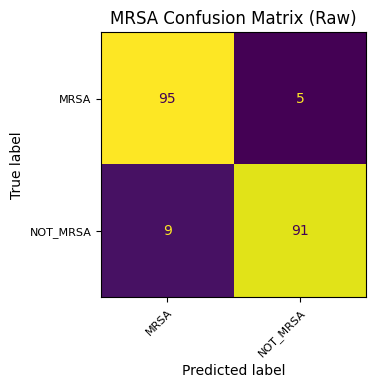


Number of errors: 14

First 10 error examples:
                                       clinical_report     label  pred_raw
589  methicillin resistant Staphylococcus aureus gr...  NOT_MRSA      MRSA
726  staph aureus {mrsa} isolated; meticillin = res...  NOT_MRSA      MRSA
385         S. aureus identified in msu; meticillin R.      MRSA  NOT_MRSA
214  MRSA cultured. meticillin reported as R. urina...      MRSA  NOT_MRSA
235  Staph aureus recovered. Susceptibility: metici...      MRSA  NOT_MRSA
723  Blood cultures grew staphylococcus lugdunensis...  NOT_MRSA      MRSA
756  staph aureus {mrsa} isolated. oxacillin non-su...  NOT_MRSA      MRSA
564         staph aureus cultured. gent reported as S.  NOT_MRSA      MRSA
49   staph aureus identified in msu; meticillin R. ...      MRSA  NOT_MRSA
52   s.aureus identified in blood cx; methicillin n...      MRSA  NOT_MRSA
MRSA - Clean
Accuracy: 0.9400

Classification Report:
              precision    recall  f1-score   support

        MRSA      

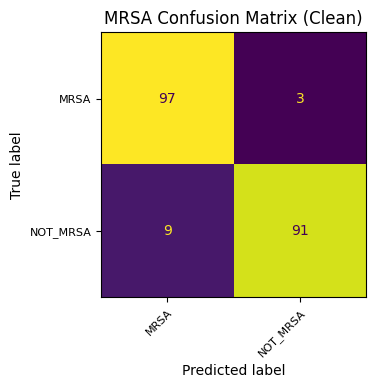


Number of errors: 12

First 10 error examples:
                                            text_clean     label pred_clean
589  methicillin resistant staphylococcus aureus gr...  NOT_MRSA       MRSA
726  staphylococcus aureus mrsa isolated meticillin...  NOT_MRSA       MRSA
511  susceptible. aureus isolated from respiratory ...  NOT_MRSA       MRSA
214  mrsa cultured. meticillin reported as resistan...      MRSA   NOT_MRSA
235  staphylococcus aureus recovered. susceptibilit...      MRSA   NOT_MRSA
723  blood cultures grew staphylococcus lugdunensis...  NOT_MRSA       MRSA
756  staphylococcus aureus mrsa isolated. oxacillin...  NOT_MRSA       MRSA
49   staphylococcus aureus identified in msu metici...      MRSA   NOT_MRSA
776  susceptible. aureus mrsa isolated from respira...  NOT_MRSA       MRSA
746  tracheal aspirate positive for staphylococcus ...  NOT_MRSA       MRSA
VRE - Raw
Accuracy: 0.9250

Classification Report:
              precision    recall  f1-score   support

     NOT_V

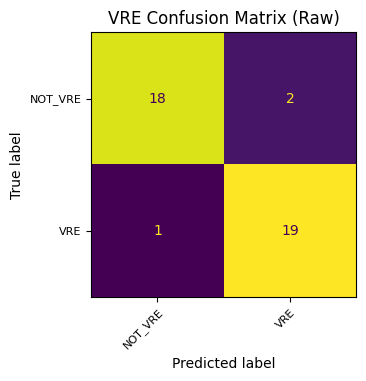


Number of errors: 3

First 3 error examples:
                                       clinical_report    label pred_raw
114  vancomycin resistant enterococcus faecium isol...  NOT_VRE      VRE
151  Bacteraemia screen: E. faecium isolated. vanc ...  NOT_VRE      VRE
32            VRE recovered. Susceptibility: vanc res.      VRE  NOT_VRE
VRE - Clean
Accuracy: 0.9500

Classification Report:
              precision    recall  f1-score   support

     NOT_VRE       1.00      0.90      0.95        20
         VRE       0.91      1.00      0.95        20

    accuracy                           0.95        40
   macro avg       0.95      0.95      0.95        40
weighted avg       0.95      0.95      0.95        40



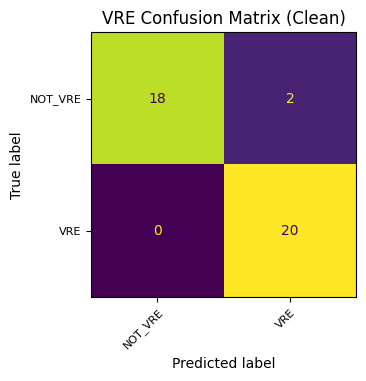


Number of errors: 2

First 2 error examples:
                                            text_clean    label pred_clean
114  vancomycin resistant enterococcus faecium isol...  NOT_VRE        VRE
151  bacteraemia screen enterococcus faecium isolat...  NOT_VRE        VRE
CRE - Raw
Accuracy: 0.9500

Classification Report:
              precision    recall  f1-score   support

         CRE       1.00      0.90      0.95        20
     NOT_CRE       0.91      1.00      0.95        20

    accuracy                           0.95        40
   macro avg       0.95      0.95      0.95        40
weighted avg       0.95      0.95      0.95        40



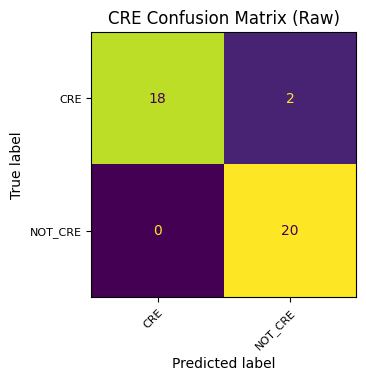


Number of errors: 2

First 2 error examples:
                                      clinical_report label pred_raw
52           MSU: K. pneumoniae isolated. imipenem R.   CRE  NOT_CRE
87  coliform, presumptive E. coli isolated from ba...   CRE  NOT_CRE
CRE - Clean
Accuracy: 0.9750

Classification Report:
              precision    recall  f1-score   support

         CRE       1.00      0.95      0.97        20
     NOT_CRE       0.95      1.00      0.98        20

    accuracy                           0.97        40
   macro avg       0.98      0.97      0.97        40
weighted avg       0.98      0.97      0.97        40



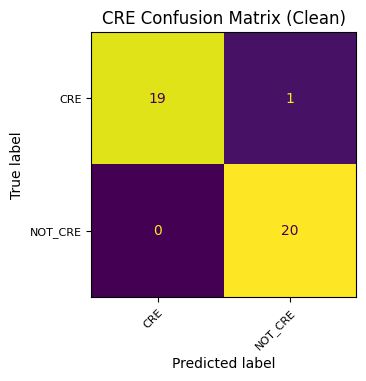


Number of errors: 1

First 1 error examples:
                                           text_clean label pred_clean
87  coliform presumptive escherichia coli isolated...   CRE    NOT_CRE
  dataset version  accuracy  n_errors
0    MRSA     Raw     0.930        14
1    MRSA   Clean     0.940        12
2     VRE     Raw     0.925         3
3     VRE   Clean     0.950         2
4     CRE     Raw     0.950         2
5     CRE   Clean     0.975         1


In [9]:
#evaluating models
evaluation_results = []

#mrsa raw and clean
evaluation_results.append(evaluate_predictions(MRSA_test, "label", "pred_raw", "clinical_report", "MRSA", "Raw"))
evaluation_results.append(evaluate_predictions(MRSA_test, "label", "pred_clean", "text_clean", "MRSA", "Clean"))

#vre raw and clean
evaluation_results.append(evaluate_predictions(VRE_test, "label", "pred_raw", "clinical_report", "VRE", "Raw"))
evaluation_results.append(evaluate_predictions(VRE_test, "label", "pred_clean", "text_clean", "VRE", "Clean"))

#cre raw and clean
evaluation_results.append(evaluate_predictions(CRE_test, "label", "pred_raw", "clinical_report", "CRE", "Raw"))
evaluation_results.append(evaluate_predictions(CRE_test, "label", "pred_clean", "text_clean", "CRE", "Clean"))

evaluation_results_df = pd.DataFrame(evaluation_results)
print(evaluation_results_df)

2. Combined multiclass direct classifier
MRSA
VRE
CRE
NONE

Again for:

raw text
cleaned text

and evaluated
accuracy
classification report
confusion matrix
error examples

In [10]:
#combining datasets
combined_df = pd.concat([MRSA_df, VRE_df, CRE_df], ignore_index=True)

In [11]:
print("Before changing negative labels to NONE:")
print(combined_df["label"].value_counts())

Before changing negative labels to NONE:
label
MRSA        500
NOT_MRSA    500
VRE         100
NOT_VRE     100
CRE         100
NOT_CRE     100
Name: count, dtype: int64


In [12]:
combined_df["label"] = combined_df["label"].replace({
    "NOT_MRSA": "NONE",
    "NOT_VRE": "NONE",
    "NOT_CRE": "NONE"
})

print("\nAfter changing negative labels to NONE:")
print(combined_df["label"].value_counts())
print("\nUnique labels:")
print(combined_df["label"].unique())


After changing negative labels to NONE:
label
NONE    700
MRSA    500
VRE     100
CRE     100
Name: count, dtype: int64

Unique labels:
<StringArray>
['MRSA', 'NONE', 'VRE', 'CRE']
Length: 4, dtype: str


In [13]:
#split combined data
combined_train, combined_test = split_data(combined_df)

print("\nCombined:", len(combined_train), len(combined_test))
print(combined_train["label"].value_counts())


Combined: 1120 280
label
NONE    560
MRSA    400
VRE      80
CRE      80
Name: count, dtype: int64


In [14]:
#train raw model
combined_raw_model, combined_raw_pred = train_and_test_model(
    combined_train,
    combined_test,
    "clinical_report",
    "label"
)
#store
combined_test["pred_raw"] = combined_raw_pred

#train cleaned model
combined_clean_model, combined_clean_pred = train_and_test_model(
    combined_train,
    combined_test,
    "text_clean",
    "label"
)
#store
combined_test["pred_clean"] = combined_clean_pred

In [15]:
#summary table for results
combined_summary_results = []

def store_combined_result(version, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    combined_summary_results.append(["Combined", version, acc])

store_combined_result("Raw", combined_test["label"], combined_test["pred_raw"])
store_combined_result("Clean", combined_test["label"], combined_test["pred_clean"])

combined_results_df = pd.DataFrame(combined_summary_results, columns=["Dataset", "Text Version", "Accuracy"])
print(combined_results_df)

    Dataset Text Version  Accuracy
0  Combined          Raw  0.957143
1  Combined        Clean  0.971429


Combined - Raw
Accuracy: 0.9571

Classification Report:
              precision    recall  f1-score   support

         CRE       1.00      0.80      0.89        20
        MRSA       0.94      1.00      0.97       100
        NONE       0.96      0.96      0.96       140
         VRE       1.00      0.90      0.95        20

    accuracy                           0.96       280
   macro avg       0.98      0.91      0.94       280
weighted avg       0.96      0.96      0.96       280



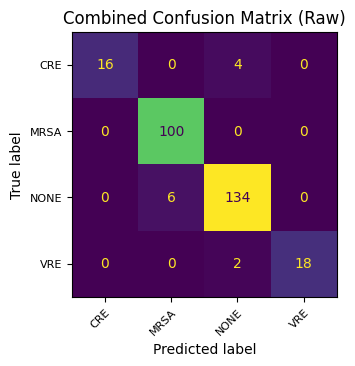


Number of errors: 12

First 10 error examples:
                                        clinical_report label pred_raw
722   STAPH AUREUS {MRSA} isolated. oxa res. methici...  NONE     MRSA
1085  Enterococcus faecium recovered. Susceptibility...   VRE     NONE
1252           MSU: K. pneumoniae isolated. imipenem R.   CRE     NONE
504            ET aspirate: MRSA isolated. oxacillin S.  NONE     MRSA
509   methicillin resistant Staphylococcus aureus gr...  NONE     MRSA
723   Blood cultures grew staphylococcus lugdunensis...  NONE     MRSA
726   staph aureus {mrsa} isolated; meticillin = res...  NONE     MRSA
1274  e.coli isolated. mero resistant. carbapenem re...   CRE     NONE
1008  enterococcus faecalis cultured. vancomycin rep...   VRE     NONE
1287  coliform, presumptive E. coli isolated from ba...   CRE     NONE
Combined - Clean
Accuracy: 0.9714

Classification Report:
              precision    recall  f1-score   support

         CRE       1.00      0.90      0.95        20
    

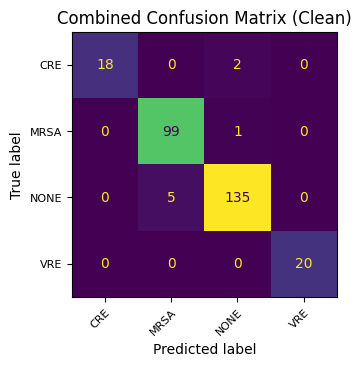


Number of errors: 8

First 8 error examples:
                                             text_clean label pred_clean
722   staphylococcus aureus mrsa isolated. oxa resis...  NONE       MRSA
189   mrsa identified in tracheal aspirate meticilli...  MRSA       NONE
509   methicillin resistant staphylococcus aureus gr...  NONE       MRSA
723   blood cultures grew staphylococcus lugdunensis...  NONE       MRSA
726   staphylococcus aureus mrsa isolated meticillin...  NONE       MRSA
1287  coliform presumptive escherichia coli isolated...   CRE       NONE
1271   escherichia coli isolated. mero non-susceptible.   CRE       NONE
589   methicillin resistant staphylococcus aureus gr...  NONE       MRSA
    dataset version  accuracy  n_errors
0  Combined     Raw  0.957143        12
1  Combined   Clean  0.971429         8


In [16]:
#evaluate
combined_evaluation_results = []

combined_evaluation_results.append(
    evaluate_predictions(combined_test, "label", "pred_raw", "clinical_report", "Combined", "Raw")
)

combined_evaluation_results.append(
    evaluate_predictions(combined_test, "label", "pred_clean", "text_clean", "Combined", "Clean")
)

combined_evaluation_results_df = pd.DataFrame(combined_evaluation_results)
print(combined_evaluation_results_df)

In [17]:
MRSA_test.to_csv("MRSA_results.csv", index=False)
VRE_test.to_csv("VRE_results.csv", index=False)
CRE_test.to_csv("CRE_results.csv", index=False)
combined_test.to_csv("combined_direct.csv", index=False)

In [18]:
#creating a table to compare models easier
# create detailed metrics table for direct classification
direct_metrics = []

#function to store values for each model
def store_direct_metrics(dataset, version, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    direct_metrics.append({
        "Dataset": dataset,
        "Text Version": version,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })


# MRSA
store_direct_metrics("MRSA", "Raw", MRSA_test["label"], MRSA_test["pred_raw"])
store_direct_metrics("MRSA", "Clean", MRSA_test["label"], MRSA_test["pred_clean"])

# VRE
store_direct_metrics("VRE", "Raw", VRE_test["label"], VRE_test["pred_raw"])
store_direct_metrics("VRE", "Clean", VRE_test["label"], VRE_test["pred_clean"])

# CRE
store_direct_metrics("CRE", "Raw", CRE_test["label"], CRE_test["pred_raw"])
store_direct_metrics("CRE", "Clean", CRE_test["label"], CRE_test["pred_clean"])

# combined multiclass model
store_direct_metrics("Combined", "Raw", combined_test["label"], combined_test["pred_raw"])
store_direct_metrics("Combined", "Clean", combined_test["label"], combined_test["pred_clean"])

# final table
direct_metrics_df = pd.DataFrame(direct_metrics).round(3)
direct_metrics_df = direct_metrics_df.sort_values(by=["Dataset", "Text Version"])
print("\nDirect classification metrics:")
print(direct_metrics_df)

# save
direct_metrics_df.to_csv("direct_classification_metrics.csv", index=False)


Direct classification metrics:
    Dataset Text Version  Accuracy  Precision  Recall     F1
5       CRE        Clean     0.975      0.976   0.975  0.975
4       CRE          Raw     0.950      0.955   0.950  0.950
7  Combined        Clean     0.971      0.972   0.971  0.971
6  Combined          Raw     0.957      0.958   0.957  0.956
1      MRSA        Clean     0.940      0.942   0.940  0.940
0      MRSA          Raw     0.930      0.931   0.930  0.930
3       VRE        Clean     0.950      0.955   0.950  0.950
2       VRE          Raw     0.925      0.926   0.925  0.925


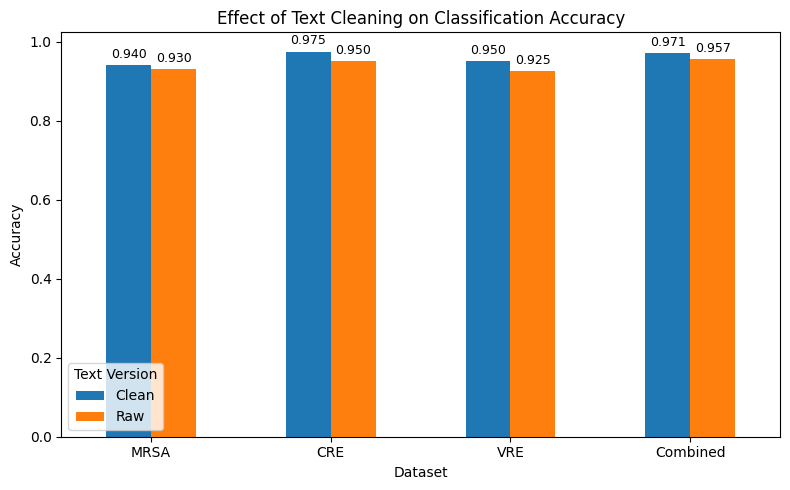

In [19]:
#graph to see accuracy of each model and compare clean vs raw

# pivot to get side by side for raw and cleaned
plot_pivot = direct_metrics_df.pivot(index="Dataset", columns="Text Version", values="Accuracy")

# set order
order = ["MRSA", "CRE", "VRE", "Combined"]
plot_pivot = plot_pivot.reindex(order)

# plot
ax = plot_pivot.plot(
    kind="bar",
    figsize=(8, 5),
)
# titles and labels
plt.title("Effect of Text Cleaning on Classification Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Dataset")
plt.xticks(rotation=0)

# add numbers on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=9, padding=3)

plt.legend(title="Text Version")
plt.tight_layout()
plt.show()



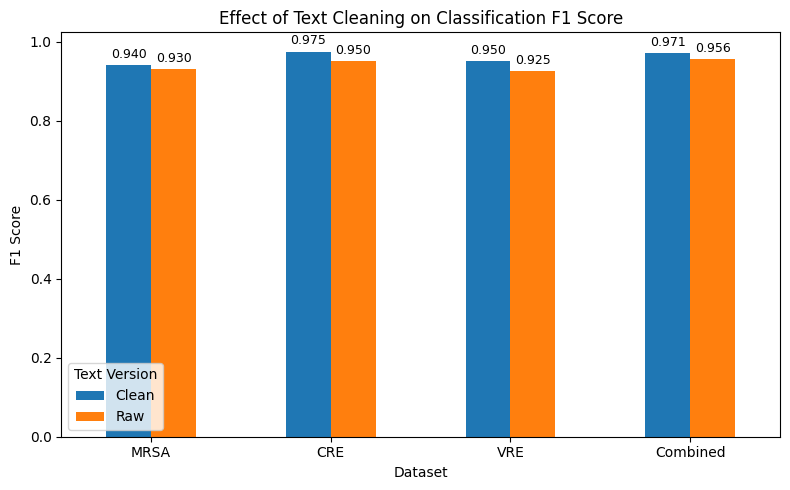

In [20]:
#graph to see F1 score of each model and compare clean vs raw

# pivot to get side by side for raw and cleaned
plot_pivot = direct_metrics_df.pivot(index="Dataset", columns="Text Version", values="F1")

# set order
order = ["MRSA", "CRE", "VRE", "Combined"]
plot_pivot = plot_pivot.reindex(order)

# plot
ax = plot_pivot.plot(
    kind="bar",
    figsize=(8, 5),
)
# titles and labels
plt.title("Effect of Text Cleaning on Classification F1 Score")
plt.ylabel("F1 Score")
plt.xlabel("Dataset")
plt.xticks(rotation=0)

# add numbers on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=9, padding=3)

plt.legend(title="Text Version")
plt.tight_layout()
plt.show()